# Multi-relational data: SQL foreign keys become graph routes

Tier C · full declared schema/query experiment. No repository imports or dataset downloads. Three live tasks; CPU only. PENDING_WRITTEN_DEFENSE.

In [ ]:
# @colab-bootstrap
import sys,subprocess
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable,'-m','pip','install','numpy==2.2.6','torch==2.8.0','torch-geometric==2.6.1'])
import importlib.metadata as metadata
print({k:metadata.version(k) for k in ['torch','torch-geometric']})


<div class="package-links"><strong>Your tangible win:</strong> turn four SQL tables into a typed graph and prove that it preserves a declared join and aggregation.<br><a href="https://avistian.github.io/relational/labs/0096-multi-relational-data.ipynb">Student notebook</a> · <a href="https://avistian.github.io/relational/labs/html/0096-multi-relational-data.html">Executed solution</a> · <a href="https://avistian.github.io/relational/reference/schema-graph-contract.html">Reference sheet</a> · <a href="https://avistian.github.io/relational/labs/l096-reproduction.md">Reproduction contract</a></div>



## 1 · Retrieve before reading

Without opening L095, write answers to these questions. Why can customer 10 and product 10 be different nodes? What information disappears when repeated interactions become one binary edge? Does reversing an edge make its information safe to use in a training graph?

<details><summary>Check after you have written</summary><p>Identity includes the node type. A binary edge discards event multiplicity and event attributes unless these are explicitly retained elsewhere. Reversing a held-out link still exposes that link. If any answer was uncertain, revisit <a href="https://avistian.github.io/relational/lessons/0095-bipartite-graphs.html">L095</a> before building.</p></details>

**The bridge.** In [L034](https://avistian.github.io/relational/lessons/0034-relational-data-without-rdl.html), joins and grouped features let a flat model use relational information. [L091](https://avistian.github.io/relational/lessons/0091-r-gcn.html) gave different edge roles different transformations. Here we decide where those roles and entities come from. This prepares the database-to-graph construction in L122. Our mission is to assess relational learning rigorously; preserving the meaning of the input comes before comparing model scores.

**Core route:** read sections 2–6, then implement the three notebook tasks. Allow about 25 minutes for the explanation and 25 for the lab. Sections 7–9 define the audit and the next retrieval session. Ask the agent whenever you cannot explain a step from the data itself.

<!-- depth-walkthrough:start -->


## The big picture · schema fidelity comes before model capacity

<div class="learning-route"><p class="route-kicker">THE BIG PICTURE · 096 / ROWS, ROLES AND IDENTITIES</p><p><strong>Bring forward:</strong> R-GCN and HGT can preserve relation meaning only if the graph builder provides it. <strong>Follow:</strong> primary keys → typed index maps → foreign-key roles → reversible graph representation → independent query audit. <strong>Carry forward:</strong> L098 introduces a second remapping from full-graph IDs to batch-local rows.</p><p><a href="https://avistian.github.io/relational/lessons/0091-r-gcn.html">L091: relation transforms</a> · <a href="https://avistian.github.io/relational/lessons/0093-hgt.html">L093: typed attention</a> · <a href="https://avistian.github.io/relational/lessons/0098-hetero-mini-batching.html">L098: batch identities</a> · <a href="https://avistian.github.io/relational/reference/0091-0100-model-map.html">Sequence map</a></p></div>

<figure class="model-map"><div class="model-map-scroll" tabindex="0" role="region" aria-label="Scrollable architecture: Database → graph · preserve rows before learning">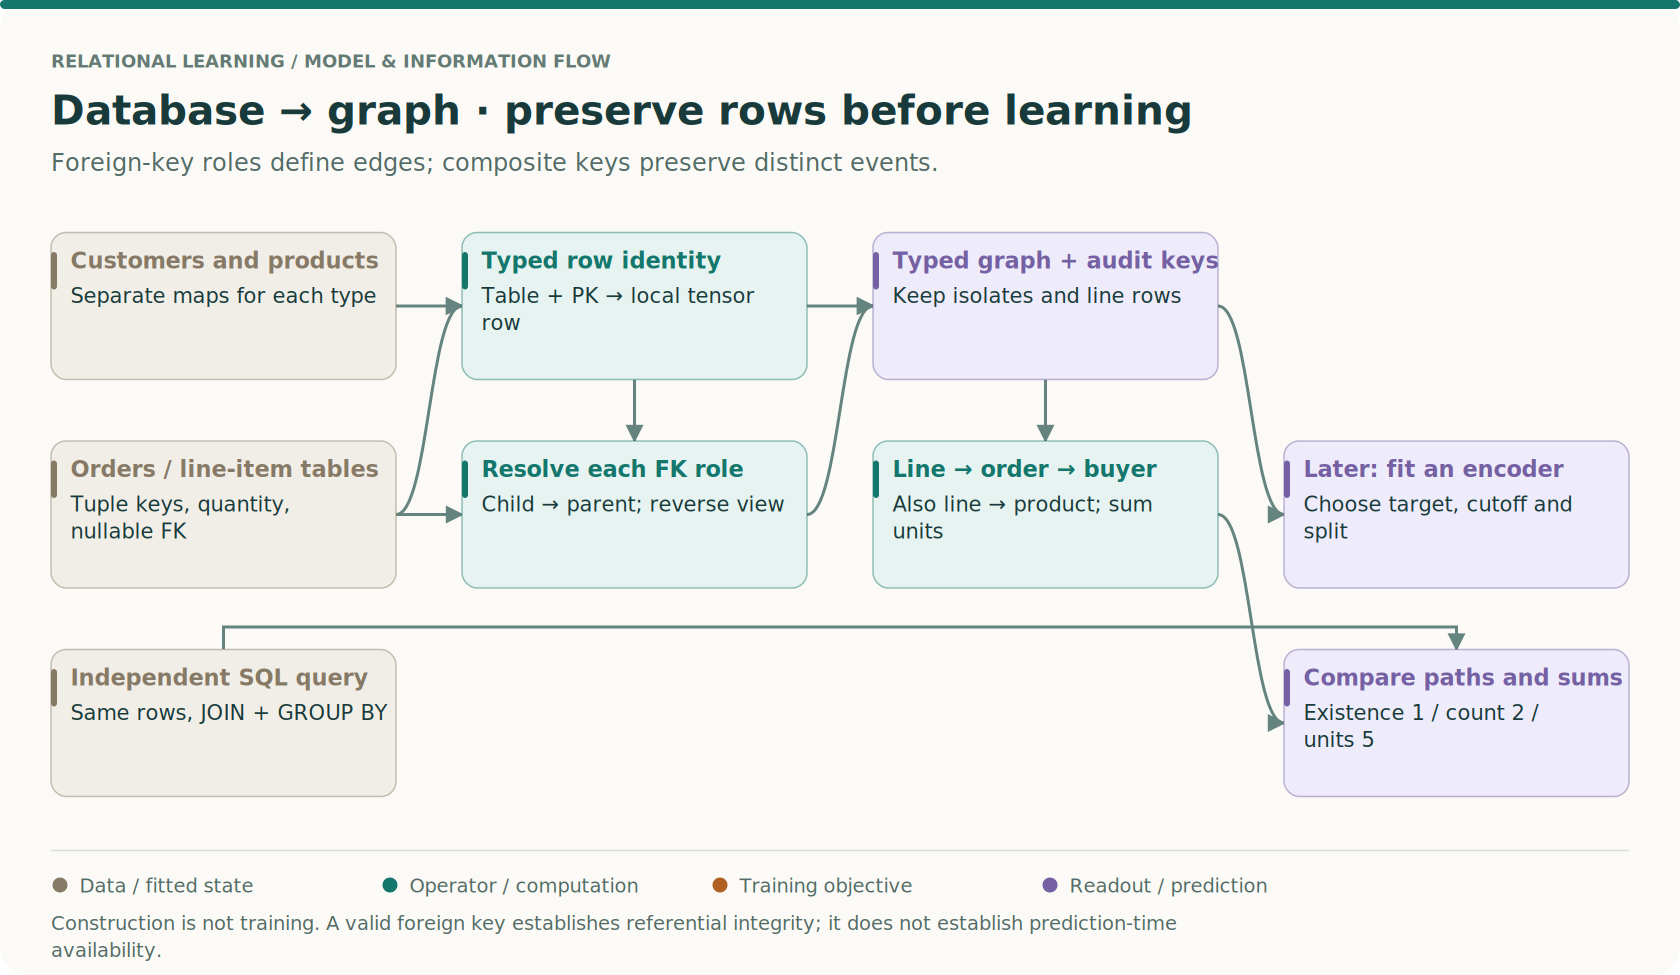</div><figcaption>Foreign-key roles define edges; composite keys preserve distinct events. Construction is not training. A valid foreign key establishes referential integrity; it does not establish prediction-time availability.</figcaption></figure>

### Decide what one node means

A customer node means a customer row. A line-item node means a complete line-item row, identified by its composite key. It does not mean a unique customer–product pair. If two lines mention the same product, their separate identities may carry separate quantities or event times. The relational graph construction described by [Fey et al.](https://arxiv.org/abs/2312.04615) motivates preserving database structure; this lesson tests construction directly, before adding a predictor.

There is no training objective in this diagram. The immediate output is a representation whose paths recover declared database relationships. Adding a GNN before checking that property can make a data error look like an architectural weakness. The independent SQL oracle below supplies a concrete falsification test.

### Trace one fact through three names

Take line key `(100,2)`, whose quantity is 3. In the line table's sorted index map it becomes local row 1. Its order key 100 becomes local order row 0. That order's buyer key 10 becomes local customer row 0. The line's product key 10 separately becomes local product row 0. The two zeros represent different entities because the table types differ.

Read the path backward to recover meaning: line local row 1 → line key `(100,2)` → order key 100 → customer key 10, plus product key 10. If the round trip cannot recover those names, a tensor shape check is not enough. L100 will repeat the same reasoning when batch row 1 maps to a different full-graph node for each type.

### Separate three questions that share the same endpoints

Customer 10 has two line paths to product 10, with quantities 2 and 3. Existence is 1; path count is 2; quantity sum is 5. A binary endpoint graph, a count matrix and an attribute-weighted path sum therefore carry different answers. A mean of quantities is 2.5. All four values can be mathematically correct while answering different questions.

This explains a limit of mean aggregation from L091. A layer that averages identical neighbor states can lose multiplicity. It does not become SQL `SUM(quantity)` because its receptive field spans the same tables. To compare the two, specify both the path structure and the reduction. You might retain explicit count features, use sum aggregation, or preserve event nodes; each choice needs its own test.

### Missing references and isolated rows are different cases

A nullable referrer means there is no referrer edge for that order. It does not delete the order. A valid customer with no orders remains a node because row existence does not depend on appearing in an edge list. A non-null referrer key with no matching customer is an integrity failure under this contract. Treating all three situations as “drop missing edges” hides different semantics. The [SQLite foreign-key reference](https://www.sqlite.org/foreignkeys.html) anchors the NULL and parent-key rules used here.

<details><summary>Try first: can sorting every table make database keys safe tensor indices?</summary><p>Sorting makes an index map deterministic. It does not make a key numerically equal to its row position. Store and use the map for each type, including complete tuples for composite keys. A key permutation should relabel the graph without changing the recovered query answer.</p></details>

**Forward connection.** Referential integrity says a parent exists; temporal availability says a prediction was allowed to use it. Neither implies the other. Before L098, write the identity of one future query as `(entity, cutoff)`, list the legal supporting rows, and explain why a reverse edge inherits the availability of its underlying fact. This prepares the mission's point-in-time relational prediction requirement without claiming that the synthetic SQL audit is a benchmark result.

<!-- depth-walkthrough:end -->



## 2 · Start with four tables and one question

Our complete, synthetic database contains customers, products, orders and line items. This is a Tier C construction lab, not a sampled extract from a hidden larger benchmark. The question is: **how many units of each product has each customer bought?** First trace the answer by hand; then make SQL and the graph agree.

| Table | Primary key | Other columns | Rows |
|---|---|---|---:|
| customer | customer_id | none in this fixture | 3 |
| product | product_id | none in this fixture | 3 |
| orders | order_id | buyer_id, nullable referrer_id | 3 |
| line_item | (order_id, line_no) | product_id, quantity | 4 |

Customers are 10, 30 and 90. Products are 10, 50 and 80. Order 100 belongs to customer 10 and was referred by customer 30; order 200 belongs to customer 30; order 300 belongs to customer 10. The last two have no referrer. Order 300 has no lines. Customer 90 and product 80 have no links.

| order_id | line_no | product_id | quantity |
|---:|---:|---:|---:|
| 100 | 1 | 10 | 2 |
| 100 | 2 | 10 | 3 |
| 100 | 3 | 50 | 1 |
| 200 | 1 | 50 | 4 |

**Predict:** customer 10 bought five units of product 10. The two matching rows are distinct because line numbers differ. A primary key can be a tuple; uniqueness applies to the complete tuple, not to each component separately. Foreign keys constrain a child reference to a matching parent key. They do not require every parent to have children. See [PostgreSQL's constraints reference](https://www.postgresql.org/docs/18/ddl-constraints.html#DDL-CONSTRAINTS-PRIMARY-KEYS).



## 3 · Specify the graph before writing tensors

<figure class="mpnn-figure"><div class="figure-scroll" tabindex="0">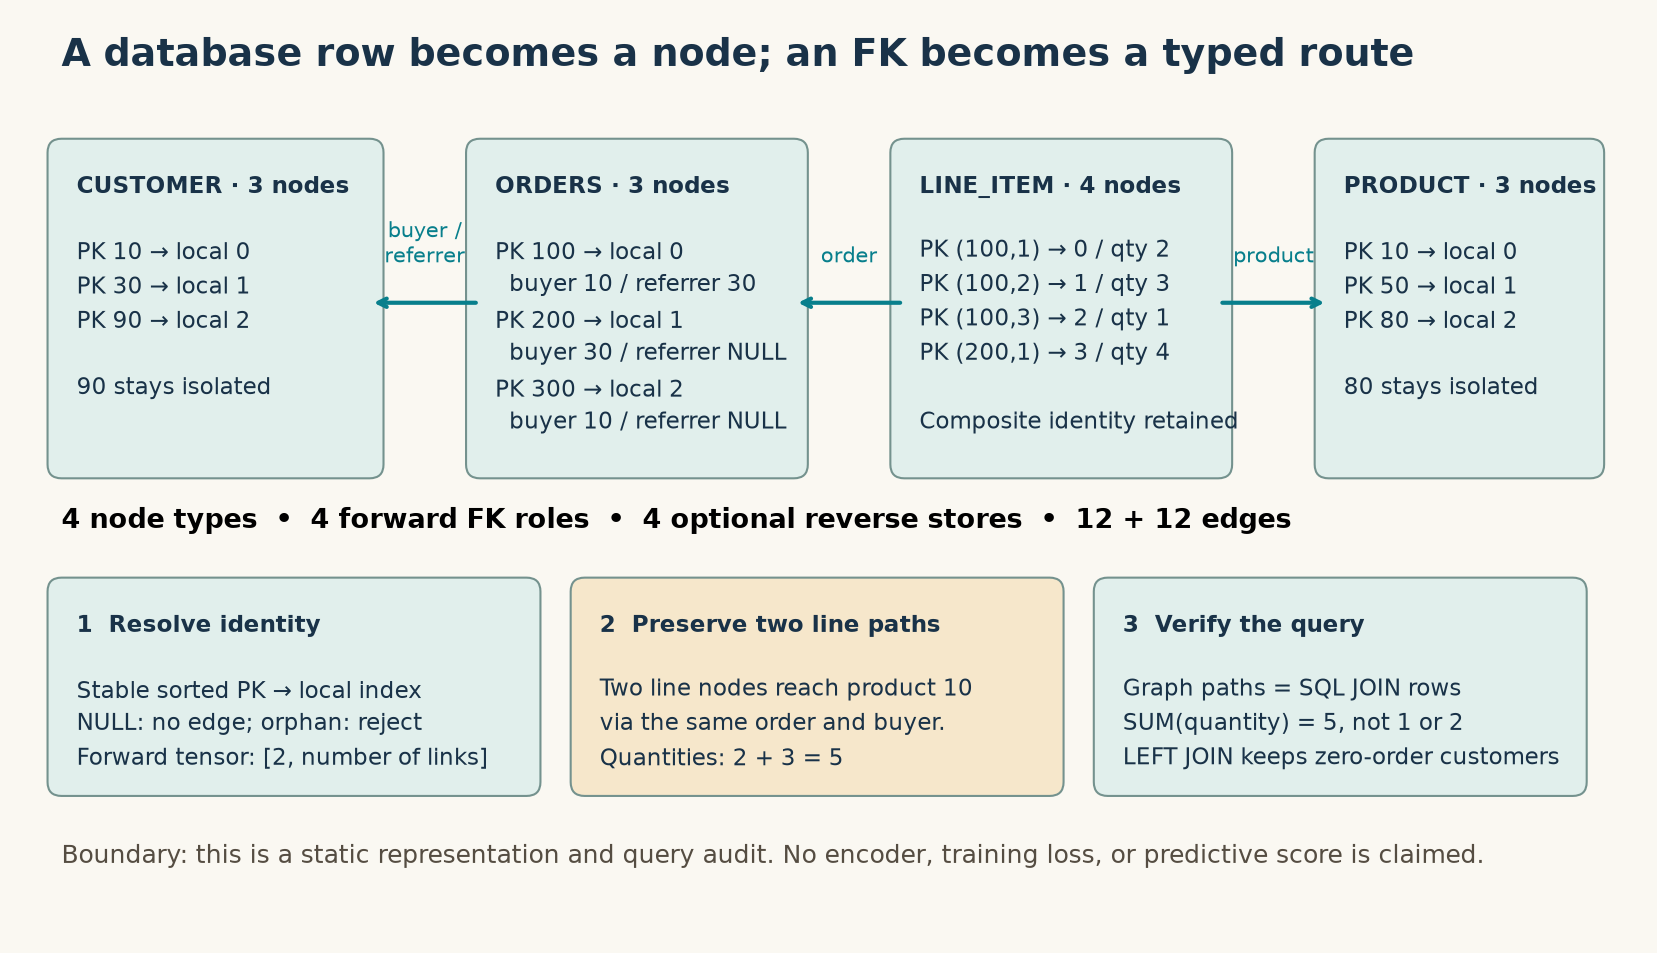</div><figcaption>The entire course fixture. Teal links are forward child-to-parent roles; reverse stores are derived views.</figcaption></figure>

The course mapping is deliberately explicit: one node type per table, one node per row, and one edge role per foreign-key constraint. The relational deep learning paper introduces database graphs as the input to representation learning; here we isolate construction from learning. Read [Fey et al., Relational Deep Learning](https://arxiv.org/abs/2312.04615) for the broader motivation; no result from that paper is a score target in this unit.

| Forward triple: source / role / destination | Number of links | Meaning |
|---|---:|---|
| orders / buyer / customer | 3 | Order identifies its buyer |
| orders / referrer / customer | 1 | Order optionally identifies its referrer |
| line_item / order / orders | 4 | Line belongs to one order |
| line_item / product / product | 4 | Line identifies one product |

**Why preserve the role?** Buyer and referrer have identical source and destination types. One generic orders→customer relation would erase which customer did what. In R-GCN or HGT, that ambiguity would already be present before the first learned transformation.

**Why this direction?** Our forward convention is child→referenced parent, because the child stores the FK. To send messages the other way, create a separate reverse store. SQL does not force an encoder's message direction. A reverse is a view of the same fact, not a new observation. The lab uses names such as `('customer','rev_orders_buyer','orders')`, making both role and originating table explicit.

A non-null FK gives each child exactly one parent for that role. Multiple children can point to the same parent: from the parent's perspective this is one-to-many. A UNIQUE constraint on the child's FK would impose an additional restriction; an FK alone does not. A many-to-many order–product relationship is represented through line rows and two FK roles. In this fixture even the same order–product pair can occur twice.



## 4 · Resolve keys; never confuse them with tensor positions

`order_id=100` is a database key. It is not necessarily tensor row 100. Sort each table's complete primary keys and create its own dictionary. Customer 10 and product 10 both become local index zero, but remain in separate stores. The line keys `(100,1)` and `(100,2)` become local indices zero and one.

```python
customer_index = {(10,): 0, (30,): 1, (90,): 2}
order_index = {(100,): 0, (200,): 1, (300,): 2}
# orders --buyer--> customer: three columns, one per order
edge_index = torch.tensor([[0, 1, 2],
                           [0, 1, 0]], dtype=torch.long)
```

PyG indexes typed edge stores by `(source, relation, destination)`; `edge_index` holds local source and destination positions. Set `num_nodes` explicitly on every node store so rows without edges survive. The graph contains 13 nodes and 12 forward links, or 24 links with the four reverse stores. These are course-fixture counts, not an empirical paper result. [PyG 2.6.1 HeteroData](https://pytorch-geometric.readthedocs.io/en/2.6.1/generated/torch_geometric.data.HeteroData.html).

**NULL is different from corruption.** Order 200's missing referrer produces no referrer edge. Replacing it with key 999 creates a dangling reference and must fail. The child order node remains in either valid nullable case; no fake customer is invented. For a nullable composite FK, the lab adopts SQLite's MATCH SIMPLE behavior: any NULL component omits the relationship. Required FKs reject NULL. The implementation explicitly enables SQLite enforcement before inserting data. [SQLite foreign-key semantics](https://www.sqlite.org/foreignkeys.html).

**Scope:** the converter accepts the declared schema with integer keys, composite row identity and PK references. It does not parse arbitrary SQL, implement collations or cascades, infer identity for keyless tables, or support references to alternate UNIQUE keys. Those need additional contracts. It stores database identities as audit metadata, not predictive features.



## 5 · A join is a path with identity and multiplicity

Trace line `(100,2)`. Its local node 1 points to order local node 0 and product local node 0. Order local node 0 points to customer local node 0. Recovering the audit keys gives `(customer=10, order=100, line=2, product=10, quantity=3)`.

The complete query has four paths, one for every line. Grouping by customer and product produces three rows:

| customer | product | SUM(quantity) |
|---:|---:|---:|
| 10 | 10 | 5 |
| 10 | 50 | 1 |
| 30 | 50 | 4 |

```sql
SELECT c.customer_id, p.product_id, SUM(l.quantity)
FROM customer c
JOIN orders o ON c.customer_id = o.buyer_id
JOIN line_item l ON o.order_id = l.order_id
JOIN product p ON l.product_id = p.product_id
GROUP BY c.customer_id, p.product_id;
```

Our graph evaluator follows three forward FK lookups from each line and sums its quantity. It does not call SQL or multiply a precomputed answer. The independent oracle creates a fresh SQLite database, inserts the same input rows, and runs the query. We compare full path tuples as well as sums: incorrect paths can accidentally yield the right total.

A plain join retains matching rows unless a query explicitly removes duplicates. Replacing this query with `DISTINCT customer,product` changes its result. For zero-order customers, a LEFT JOIN plus `COUNT(o.order_id)` returns zero; `COUNT(*)` counts the retained outer row. [SQLite SELECT processing](https://www.sqlite.org/lang_select.html).

**Three different answers:** existence of customer 10→product 10 is 1; its number of line paths is 2; its sum of quantities is 5. A binary projection, path count and weighted aggregation answer different questions. A mean message aggregator also does not automatically implement a SQL sum. No generic GNN is promised to reproduce arbitrary SQL semantics.

**Portable intervention:** use the prediction and intervention cell after the implementation.

**Before touching the control:** move line `(100,2)` from product 10 to product 50. Predict both totals. Then explain why the line-node count stays four. The notebook runs this same intervention against the SQL oracle.



## 6 · Implement the three load-bearing steps

All code is visible inline in both notebooks. The student notebook contains three blanks; the solution contains their implementations. Each task has an immediate CHECK, and the final 33-database audit uses those same functions.

1. **TODO: `key_index`.** Reject missing or duplicate composite keys and build stable per-table indices. **CHECK:** `(100,1)` and `(100,2)` are distinct; repeated `(100,1)` fails; input reordering cannot change IDs.
2. **TODO: `fk_edges`.** Resolve each child reference through the parent map. Retain the child's position after skipping NULL; return `[2,0]` for an empty relation. **CHECK:** nullable rows are skipped, orphans fail, and every remaining destination is correct.
3. **TODO: `graph_query`.** Follow line→order→buyer and line→product; preserve every line, sum quantities and include zero-order customers. **CHECK:** all path tuples, all sums and all customer counts equal the independent SQL result.

The supplied graph builder applies the first two steps to all four FK roles, stores quantities, and creates exact reversed edge tensors. The SQL oracle and generated fixtures are also visible. The entire construction runs on CPU; there is no hidden remote trainer or saved model behind the lab.

**Representation is not a prediction task.** If predicting future purchases, you still need an as-of cutoff, allowed features and a label window. Structural validity does not prove availability at prediction time. Removing a direct customer–product target edge would not hide an order/line path that still reveals the same future purchase. L097 next studies negative sampling; L098 introduces mini-batching; L122 returns to full relational entity graph construction. Those future units are not prerequisites for this lab.



## 7 · Reproduce the whole declared experiment

**Author execution: PASS.** All 33 declared databases have exact equality of graph and SQL paths, totals and customer-order counts. These are frozen author results; your notebook recomputes them from scratch.

The full target is the supplied 13-row database plus 32 deterministically generated databases (seeds 0–31). Every generated database has seven customers, six products and twelve orders; all its generated line rows are used. The last customer and product are deliberately unreferenced. There is no subsampling and no unexecuted larger run being substituted with this fixture suite.

Reproducibility here means **the same inputs, mapping, query and expected outputs**, with recorded source/data hashes and environment. Separate tests cover duplicate and NULL keys, dangling references, empty relations, optional composite FKs, reverse stores, 20 row-order permutations and the product reassignment. A finite suite is evidence for the declared implementation; it is not a proof for every SQL database.

| Evidence | Claim boundary |
|---|---|
| Complete course suite | All 33 databases; paths, totals and outer counts checked against SQL |
| Paper-result reproduction | NOT_APPLICABLE_NO_MODEL_PAPER: curriculum specifies a bridge unit |
| Historical predictive-score parity | NOT_ESTABLISHED: no trained model or score target |
| Local standalone notebook | See execution evidence; does not imply live Colab |
| Live Colab / deployed site | NOT_CHECKED |
| Learner mastery | PENDING_WRITTEN_DEFENSE |

See the [exact commands and deviations](https://avistian.github.io/relational/labs/l096-reproduction.md), [behavioral checks](https://avistian.github.io/relational/labs/_verify_l096_results.json), [full query outputs](https://avistian.github.io/relational/labs/_experiment_l096_results.json), and [notebook execution](https://avistian.github.io/relational/labs/_execution_l096_results.json). This respects the request for full reproduction by completing the entire specified construction experiment and naming precisely what has no applicable paper target.



## 8 · Written defense and spaced retrieval

Before opening the solution, submit your graph spec and these answers to the agent:

- List all node types, all forward roles and their reverses. Explain why two orders→customer roles cannot be merged.
- Trace line `(100,2)` from original PKs to local IDs and back. Distinguish existence, path count and quantity sum.
- Explain NULL versus orphan, and why customer 90 and product 80 must remain nodes.
- Show that your query keeps customer 90 with zero orders. Explain why COUNT(*) would differ.
- Report exactly what was reproduced and one limitation of the integer-key converter.
- Describe how a future order could leak a purchase target through an indirect path.

**Pass criterion:** correct identities and roles, four retained paths, totals 5/1/4, zero-order preservation, correct failure behavior, and a bounded reproduction claim. Execution alone is insufficient. Revisit tomorrow with the tables hidden; in one week, add a second nullable FK to product and explain how your spec changes before implementing it.



## 9 · Primary reading

Start with [SQLite foreign keys, sections 1–2](https://www.sqlite.org/foreignkeys.html): reproduce the distinction between a missing parent and a NULL reference. Use [PostgreSQL PK/FK constraints](https://www.postgresql.org/docs/18/ddl-constraints.html) for the schema terminology and [PyG's typed container](https://pytorch-geometric.readthedocs.io/en/2.6.1/generated/torch_geometric.data.HeteroData.html) for storage. Then read [Fey et al.](https://arxiv.org/abs/2312.04615) with one question: which information must a database graph preserve before learned aggregation begins?


## Visible implementation

Read the schema constants first. A supplied SQL engine will serve as an independent oracle; it never calls your graph evaluator.

In [ ]:
from collections import Counter

import hashlib

import json

import random

import sqlite3

import torch

from torch_geometric.data import HeteroData

PKS = {'customer':('customer_id',), 'product':('product_id',),
       'orders':('order_id',), 'line_item':('order_id','line_no')}

FKS = [('orders','buyer',('buyer_id',),'customer',('customer_id',),False),
       ('orders','referrer',('referrer_id',),'customer',('customer_id',),True),
       ('line_item','order',('order_id',),'orders',('order_id',),False),
       ('line_item','product',('product_id',),'product',('product_id',),False)]

DDL = '''
CREATE TABLE customer(customer_id INTEGER PRIMARY KEY NOT NULL);
CREATE TABLE product(product_id INTEGER PRIMARY KEY NOT NULL);
CREATE TABLE orders(order_id INTEGER PRIMARY KEY NOT NULL,
 buyer_id INTEGER NOT NULL REFERENCES customer(customer_id),
 referrer_id INTEGER REFERENCES customer(customer_id));
CREATE TABLE line_item(order_id INTEGER NOT NULL REFERENCES orders(order_id),
 line_no INTEGER NOT NULL, product_id INTEGER NOT NULL REFERENCES product(product_id),
 quantity INTEGER NOT NULL CHECK(quantity>0), PRIMARY KEY(order_id,line_no));
'''

COLUMNS = {'customer':('customer_id',), 'product':('product_id',),
 'orders':('order_id','buyer_id','referrer_id'),
 'line_item':('order_id','line_no','product_id','quantity')}

### PROVIDED · fixture

All 13 rows of the complete hand-traceable course database.

In [ ]:
def fixture():
    """All 13 rows of the complete hand-traceable course database."""
    return {'customer':[{'customer_id':v} for v in [10,30,90]],
     'product':[{'product_id':v} for v in [10,50,80]],
     'orders':[dict(order_id=100,buyer_id=10,referrer_id=30),
               dict(order_id=200,buyer_id=30,referrer_id=None),
               dict(order_id=300,buyer_id=10,referrer_id=None)],
     'line_item':[dict(order_id=o,line_no=n,product_id=p,quantity=q)
                   for o,n,p,q in [(100,1,10,2),(100,2,10,3),(100,3,50,1),(200,1,50,4)]]}

### TODO · key_index

Reject missing/noninteger or duplicate PKs; stable lexicographic local IDs.

In [ ]:
def key_index(rows, columns):
    raise NotImplementedError("Implement the declared contract")

### CHECK · key_index

In [ ]:
assert key_index([{'a':100,'b':2},{'a':100,'b':1}],('a','b'))=={(100,1):0,(100,2):1}
for rows in [[{'a':1},{'a':1}],[{'a':None}]]:
    try: key_index(rows,('a',))
    except ValueError: pass
    else: raise AssertionError('Invalid PK accepted')
print('PASS: composite keys, stable ordering, invalid keys rejected')

### TODO · fk_edges

Rows are in child-local order. NULL omits an edge; orphan keys fail.

In [ ]:
def fk_edges(rows, columns, parent_index, nullable):
    raise NotImplementedError("Implement the declared contract")

### CHECK · fk_edges

In [ ]:
e=fk_edges([{'p':None},{'p':30}],('p',),{(10,):0,(30,):1},True)
assert e.tolist()==[[1],[1]]
assert fk_edges([],('p',),{},True).shape==(2,0)
for value,nullable in [(999,True),(None,False)]:
    try: fk_edges([{'p':value}],('p',),{(10,):0},nullable)
    except ValueError: pass
    else: raise AssertionError('Invalid FK accepted')
print('PASS: NULL, orphan and empty relation contracts')

### PROVIDED · build_graph

One node per row. One role-specific forward and reverse store per FK.

In [ ]:
def build_graph(tables):
    """One node per row. One role-specific forward and reverse store per FK."""
    if set(tables)!=set(PKS):raise ValueError('Expected exactly the four declared tables')
    indices={t:key_index(tables[t],pk) for t,pk in PKS.items()}
    ordered={t:sorted(tables[t],key=lambda r:tuple(r[c] for c in PKS[t])) for t in PKS}
    g=HeteroData()
    for table in PKS:
        g[table].num_nodes=len(ordered[table])
        g[table].primary_keys=list(indices[table]) # Audit identity, not model features.
    quantity=[r['quantity'] for r in ordered['line_item']]
    if any(type(q) is not int or q<=0 for q in quantity):raise ValueError('Positive integer quantities required')
    g['line_item'].quantity=torch.tensor(quantity,dtype=torch.long)
    for child,role,cols,parent,parentcols,nullable in FKS:
        if parentcols!=PKS[parent]:raise ValueError('This explicit builder references PKs only')
        e=fk_edges(ordered[child],cols,indices[parent],nullable)
        g[child,role,parent].edge_index=e
        g[parent,'rev_'+child+'_'+role,child].edge_index=e.flip(0).clone()
    g.validate(raise_on_error=True)
    return g

### TODO · graph_query

Join by typed IDs, keep each line, then SUM quantities and count orders.

In [ ]:
def graph_query(g):
    raise NotImplementedError("Implement the declared contract")

### CHECK · graph_query

In [ ]:
g=build_graph(fixture())
answer=graph_query(g)
assert answer=={'paths':[[10,100,1,10,2],[10,100,2,10,3],[10,100,3,50,1],[30,200,1,50,4]],'totals':[[10,10,5],[10,50,1],[30,50,4]],'customer_order_counts':[[10,2],[30,1],[90,0]]}
print('PASS: all paths, quantities and isolated customer preserved')

### PROVIDED · sql_query

Independent oracle: SQLite performs constraints, joins, SUM and LEFT JOIN.

In [ ]:
def sql_query(tables):
    """Independent oracle: SQLite performs constraints, joins, SUM and LEFT JOIN."""
    db=sqlite3.connect(':memory:')
    try:
        db.execute('PRAGMA foreign_keys=ON')
        assert db.execute('PRAGMA foreign_keys').fetchone()==(1,)
        db.executescript(DDL)
        for table,cols in COLUMNS.items():
            marks=','.join('?' for _ in cols)
            db.executemany(f'INSERT INTO {table} VALUES ({marks})',
                           [tuple(r[c] for c in cols) for r in tables[table]])
        join='FROM customer c JOIN orders o ON c.customer_id=o.buyer_id JOIN line_item l ON o.order_id=l.order_id JOIN product p ON l.product_id=p.product_id'
        paths=db.execute('SELECT c.customer_id,o.order_id,l.line_no,p.product_id,l.quantity '+join+' ORDER BY 1,2,3,4,5').fetchall()
        totals=db.execute('SELECT c.customer_id,p.product_id,SUM(l.quantity) '+join+' GROUP BY c.customer_id,p.product_id ORDER BY 1,2').fetchall()
        counts=db.execute('SELECT c.customer_id,COUNT(o.order_id) FROM customer c LEFT JOIN orders o ON c.customer_id=o.buyer_id GROUP BY c.customer_id ORDER BY 1').fetchall()
        return {'paths':[list(x) for x in paths],'totals':[list(x) for x in totals],
                'customer_order_counts':[list(x) for x in counts]}
    finally:db.close()

### PROVIDED · generated_fixture

Fixed coverage extension: 32 seeds, 7 customers, 6 products, 12 orders.

In [ ]:
def generated_fixture(seed):
    """Fixed coverage extension: 32 seeds, 7 customers, 6 products, 12 orders."""
    rng=random.Random(seed);cs=[10+11*i for i in range(7)];ps=[10+13*i for i in range(6)]
    tables={'customer':[{'customer_id':v} for v in cs],
            'product':[{'product_id':v} for v in ps], 'orders':[], 'line_item':[]}
    for i in range(12):
        oid=100+7*i
        tables['orders'].append(dict(order_id=oid,buyer_id=rng.choice(cs[:-1]),referrer_id=rng.choice([None]+cs)))
        for j in range(rng.randrange(6)):
            tables['line_item'].append(dict(order_id=oid,line_no=j+1,product_id=rng.choice(ps[:-1]),quantity=rng.randint(1,9)))
    return tables

### PROVIDED · run_suite

Execute the complete declared fixture suite; never sample a larger target.

In [ ]:
def run_suite():
    """Execute the complete declared fixture suite; never sample a larger target."""
    records=[]
    for name,t in [('worked',fixture())]+[(f'seed-{s}',generated_fixture(s)) for s in range(32)]:
        g=build_graph(t);actual=graph_query(g);expected=sql_query(t)
        assert actual==expected, name
        records.append({'name':name,'data_sha256':hashlib.sha256(json.dumps(t,sort_keys=True).encode()).hexdigest(),
          'nodes':{k:g[k].num_nodes for k in g.node_types},
          'edges':{'|'.join(k):g[k].edge_index.shape[1] for k in g.edge_types},'query':actual})
    return {'status':'PASS','scope':'Complete course fixture suite; no model-paper experiment',
            'databases':len(records),'records':records,'full_paper_parity':'NOT_APPLICABLE_NO_MODEL_PAPER'}

## Predict → intervene → explain

Move line (100,2) to product 50. Write the new customer 10 totals before executing. Which keys and row counts stay fixed?

In [ ]:
changed=fixture();changed['line_item'][1]['product_id']=50
after=graph_query(build_graph(changed))
assert after==sql_query(changed)
assert after['totals']==[[10,10,2],[10,50,4],[30,50,4]]
print(after)

## Complete reproduction run

Run all 33 declared databases afresh. The hash comparison below uses labeled frozen author references; SQLite still independently recomputes every expected query.

In [ ]:
fresh=run_suite()
AUTHOR_RECORDS_SHA256='b96c1b691c552ee80a1ae1aea4768d4259ef58f65e41143367c00c23736f7e70'
assert hashlib.sha256(json.dumps(fresh["records"],sort_keys=True).encode()).hexdigest()==AUTHOR_RECORDS_SHA256
from pathlib import Path
Path("l096-fresh.json").write_text(json.dumps(fresh,indent=2))
print(f"PASS: {fresh['databases']} complete databases, every path, total and outer count")

## EXIT · PENDING_WRITTEN_DEFENSE

Submit the graph specification, the complete-suite output and your section 8 written defense. Explain the two role names, composite identity, the 1/2/5 distinction, NULL versus orphan, and one temporal leakage route. Ask the agent for feedback. Teacher execution is not learner mastery.